In [1]:
import json

id2label = {
    0: "B-LOC",
    1: "B-MISC",
    2: "B-ORG",
    3: "B-PER",
    4: "I-LOC",
    5: "I-MISC",
    6: "I-ORG",
    7: "I-PER",
    8: "O"
}

def load(path):
    return [json.loads(line) for line in open(path, "r", encoding="utf8")]

def extract_spans(tokens, tags):
    spans = []
    current = None

    for i, tag_id in enumerate(tags):
        tag = id2label[tag_id]

        if tag == "O":
            if current:
                spans.append(current)
                current = None
            continue

        prefix, label = tag.split("-")

        if prefix == "B":
            if current:
                spans.append(current)
            current = {"label": label, "start": i, "end": i+1}

        elif prefix == "I":
            if current and current["label"] == label:
                current["end"] = i+1
            else:
                # I-X without matching B-X → treat as new entity
                current = {"label": label, "start": i, "end": i+1}

    if current:
        spans.append(current)

    # Convert to readable form
    readable = []
    for s in spans:
        text = " ".join(tokens[s["start"]:s["end"]])
        readable.append((s["label"], text))
    return readable
disagree = []
def analyze(a1, a2, a3):
    A = load(a1)
    B = load(a2)
    C = load(a3)
    base = load("test_pred_base.jsonl")
    bertweet = load("bertweet_pred.jsonl")
    gold = load("test.jsonl")

    for idx, (x, y, z,b,btweet,g) in enumerate(zip(A, B, C,base,bertweet,gold)):
        spansA = extract_spans(x["tokens"], x["tags"])
        spansB = extract_spans(y["tokens"], y["tags"])
        spansC = extract_spans(z["tokens"], z["tags"])
        spans_base = extract_spans(b["tokens"],b["tags"])
        spans_bertweet = extract_spans(btweet["tokens"],btweet["tags"])
        spans_gold = extract_spans(g["tokens"],g["tags"])

        if not (spansA == spansB == spansC):
            disagree.append(idx)
            print("="*80)
            print(f"TWEET {idx}")
            print("TOKENS:", " ".join(x["tokens"]))
            print()
            print("Annotator A:", spansA)
            print("Annotator B:", spansB)
            print("Annotator C:", spansC)
            print("Baseline:", spans_base)
            print("Bertweet:", spans_bertweet)
            print("Gold standard", spans_gold)
            print()

# Example:
analyze("val_500.jsonl", "Hjalte_500.jsonl", "mar_500.jsonl")
print(disagree)

TWEET 6
TOKENS: RT @USER445 : Spine - Chilling Stories of Real Life Cannibals , Horrible ! URL1310 URL1455

Annotator A: []
Annotator B: []
Annotator C: [('MISC', 'Spine')]
Baseline: []
Bertweet: []
Gold standard []

TWEET 7
TOKENS: I 've entered for a chance to win a copy of @USER1136 on XB1 from @USER1071 thanks to @USER718 ! Enter HERE : URL1617

Annotator A: [('MISC', 'XB1')]
Annotator B: [('ORG', 'XB1')]
Annotator C: [('ORG', 'XB1')]
Baseline: []
Bertweet: [('MISC', 'XB1')]
Gold standard []

TWEET 11
TOKENS: RT @USER487 : Where is AKMU Where is MADE full album Where is EXIT : X Where is YGGG Saddest ? Where is Minzy ?

Annotator A: [('MISC', 'AKMU'), ('MISC', 'MADE'), ('MISC', 'EXIT'), ('MISC', 'YGGG Saddest'), ('PER', 'Minzy')]
Annotator B: [('MISC', 'AKMU'), ('MISC', 'MADE'), ('MISC', 'EXIT'), ('MISC', 'YGGG'), ('PER', 'Minzy')]
Annotator C: [('PER', 'AKMU'), ('PER', 'Minzy')]
Baseline: [('ORG', 'AKMU'), ('MISC', 'MADE'), ('PER', 'YGGG'), ('PER', 'Minzy')]
Bertweet: [('ORG', 'AK

[0, 1, 2, 3, 4, 5, 8, 9, 10, 13, 14, 16, 17, 21, 25, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 44, 45, 46, 47, 48, 49, 51, 52, 53, 55, 56, 57, 58, 59, 60, 62, 63, 64, 65, 67, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 82, 83, 86, 87, 88, 89, 92, 93, 97, 101, 102, 103, 104, 105, 108, 109, 110, 113, 114, 115, 116, 119, 120, 121, 122, 123, 124, 126, 127, 128, 129, 131, 134, 135, 136, 138, 139, 140, 141, 142, 143, 145, 147, 149, 150, 151, 152, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 167, 169, 170, 171, 172, 173, 174, 176, 177, 178, 179, 180, 182, 183, 184, 186, 188, 189, 191, 192, 193, 194, 196, 198, 200, 201, 202, 206, 207, 209, 210, 211, 213, 214, 215, 216, 217, 218, 219, 222, 223, 224, 225, 226, 227, 229, 231, 232, 233, 236, 237, 238, 239, 242, 244, 245, 246, 248, 249, 251, 253, 254, 258, 259, 260, 261, 262, 264, 265, 266, 270, 272, 274, 275, 276, 277, 278, 279, 280, 281, 282, 285, 286, 288, 289, 290, 292, 294, 295, 296, 297, 298, 301, 302, 303, 304, 30

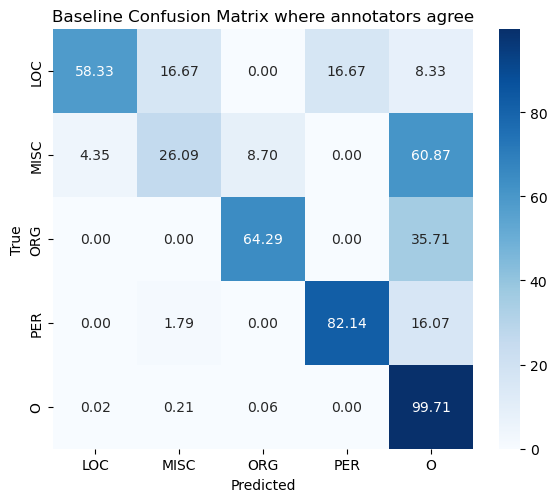

In [5]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
counts = [0 for _ in range(5)]

labels = ["LOC", "MISC", "ORG", "PER", "O"]
label2id = {l: i for i, l in enumerate(labels)}

# rows = gold, cols = predicted
token_labels = [[0 for _ in labels] for _ in labels]

def strip_bio(tag):
    if tag == "O":
        return "O"
    return tag.split("-")[1]

base = load("test_pred_base.jsonl")
base = [base[i] for i in range(500) if i not in disagree]

gold = load("test.jsonl")
gold = [gold[i] for i in range(500) if i not in disagree]
print([i for i in range(500) if i not in disagree])

for pred_ex, gold_ex in zip(base, gold):

    pred_tags = pred_ex["tags"]
    gold_tags = gold_ex["tags"]

    for P, G in zip(pred_tags, gold_tags):

        pred_label = strip_bio(id2label[P])
        gold_label = strip_bio(id2label[G])

        pred_idx = label2id[pred_label]
        gold_idx = label2id[gold_label]
        counts[gold_idx] += 1

        token_labels[gold_idx][pred_idx] += 1


for i in range(len(token_labels)):
    for j in range(len(token_labels)):
        token_labels[i][j]/= counts[i]
        token_labels[i][j]*=100
        token_labels[i][j] = round(token_labels[i][j],2)
df = pd.DataFrame(
    token_labels,
    index=labels, 
    columns=labels    
)
print(df)
print(counts)
plt.figure(figsize=(6, 5))

sns.heatmap(
    df,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    square=True
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Baseline Confusion Matrix where annotators agree")

plt.tight_layout()
plt.savefig("baseline_agree.png")
plt.show()


        LOC   MISC    ORG     PER      O
LOC   75.00   0.00  16.67    8.33   0.00
MISC   0.00  34.78   4.35   17.39  43.48
ORG    0.00   0.00  71.43    7.14  21.43
PER    0.00   0.00   0.00  100.00   0.00
O      0.02   0.12   0.08    0.02  99.75
[12, 23, 14, 56, 4801]


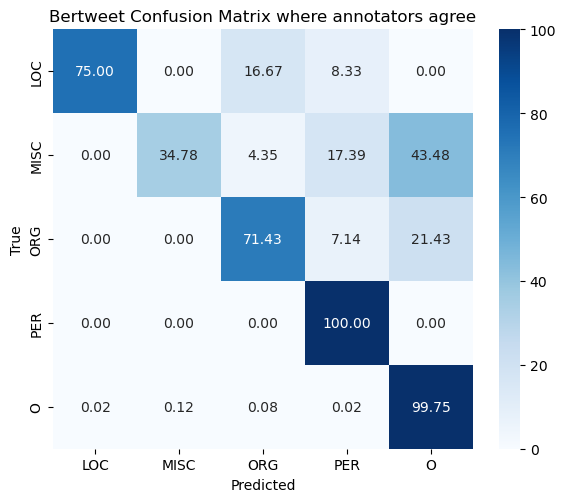

In [6]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
counts = [0 for _ in range(5)]

labels = ["LOC", "MISC", "ORG", "PER", "O"]
label2id = {l: i for i, l in enumerate(labels)}

token_labels = [[0 for _ in labels] for _ in labels]

def strip_bio(tag):
    if tag == "O":
        return "O"
    return tag.split("-")[1]

base = load("bertweet_pred.jsonl")
base = [base[i] for i in range(500) if i not in disagree]

gold = load("test.jsonl")
gold = [gold[i] for i in range(500) if i not in disagree]

for pred_ex, gold_ex in zip(base, gold):

    pred_tags = pred_ex["tags"]
    gold_tags = gold_ex["tags"]

    for P, G in zip(pred_tags, gold_tags):

        pred_label = strip_bio(id2label[P])
        gold_label = strip_bio(id2label[G])

        pred_idx = label2id[pred_label]
        gold_idx = label2id[gold_label]
        counts[gold_idx] += 1

        token_labels[gold_idx][pred_idx] += 1


for i in range(len(token_labels)):
    for j in range(len(token_labels)):
        token_labels[i][j]/= counts[i]
        token_labels[i][j]*=100
        token_labels[i][j] = round(token_labels[i][j],2)
df = pd.DataFrame(
    token_labels,
    index=labels, 
    columns=labels    
)
print(df)
print(counts)
plt.figure(figsize=(6, 5))

sns.heatmap(
    df,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    square=True
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Bertweet Confusion Matrix where annotators agree")

plt.tight_layout()
plt.savefig("bertweet_agree.png")
plt.show()



In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
counts = [0 for _ in range(5)]

labels = ["LOC", "MISC", "ORG", "PER", "O"]
label2id = {l: i for i, l in enumerate(labels)}

# rows = gold, cols = predicted
token_labels = [[0 for _ in labels] for _ in labels]

def strip_bio(tag):
    if tag == "O":
        return "O"
    return tag.split("-")[1]

base = load("test_pred_base.jsonl")
base = [base[i] for i in range(len(base)) if i not in disagree]

gold = load("test.jsonl")
gold = [gold[i] for i in range(len(gold)) if i not in disagree]

for pred_ex, gold_ex in zip(base, gold):

    pred_tags = pred_ex["tags"]
    gold_tags = gold_ex["tags"]

    for P, G in zip(pred_tags, gold_tags):

        pred_label = strip_bio(id2label[P])
        gold_label = strip_bio(id2label[G])

        pred_idx = label2id[pred_label]
        gold_idx = label2id[gold_label]
        counts[gold_idx] += 1

        token_labels[gold_idx][pred_idx] += 1


for i in range(len(token_labels)):
    for j in range(len(token_labels)):
        token_labels[i][j]/= counts[i]
        token_labels[i][j]*=100
        token_labels[i][j] = round(token_labels[i][j],2)
df = pd.DataFrame(
    token_labels,
    index=labels, 
    columns=labels    
)
print(df)
print(counts)
plt.figure(figsize=(6, 5))

sns.heatmap(
    df,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    square=True
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Baseline Confusion Matrix where annotators disagree")

plt.tight_layout()
plt.savefig("baseline.png")
plt.show()


In [2]:
def count_disagreements(a1, a2, a3):
    A = load(a1)
    B = load(a2)
    C = load(a3)

    total_tweets = len(A)
    disagree_tweets = 0
    total_tokens = 0
    tokens_labeled_by_someone = 0
    token_disagreements = 0

    for x, y, z in zip(A, B, C):
        spansA = extract_spans(x["tokens"], x["tags"])
        spansB = extract_spans(y["tokens"], y["tags"])
        spansC = extract_spans(z["tokens"], z["tags"])

        # Count tokens
        total_tokens += len(x["tokens"])

        # Count tokens where at least one annotator labeled something ≠ O (8)
        for tA, tB, tC in zip(x["tags"], y["tags"], z["tags"]):
            if not (tA == 8 and tB == 8 and tC == 8):
                tokens_labeled_by_someone += 1

        # Tweet-level disagreement
        if not (spansA == spansB == spansC):
            disagree_tweets += 1

            # Token-level disagreement count
            for tA, tB, tC in zip(x["tags"], y["tags"], z["tags"]):
                if not (tA == tB == tC):
                    token_disagreements += 1

    print("=== DISAGREEMENT SUMMARY ===")
    print(f"Total tweets: {total_tweets}")
    print(f"Tweets with disagreement: {disagree_tweets}")
    print(f"Tweets with full agreement: {total_tweets - disagree_tweets}")
    print()

    print(f"Tokens labeled by at least one annotator: {tokens_labeled_by_someone}")
    print(f"Total tokens: {total_tokens}")
    print()

    print(f"Tokens with disagreement: {token_disagreements}")
    print(f"Agreement rate (tokens): {(1 - token_disagreements/total_tokens):.4f}")
    print(f"Disagreement rate (tokens): {(token_disagreements/total_tokens):.4f}")

# Example usage:
count_disagreements("val_500.jsonl", "Hjalte_500.jsonl", "mar_500.jsonl")


=== DISAGREEMENT SUMMARY ===
Total tweets: 500
Tweets with disagreement: 154
Tweets with full agreement: 346

Tokens labeled by at least one annotator: 545
Total tokens: 7658

Tokens with disagreement: 361
Agreement rate (tokens): 0.9529
Disagreement rate (tokens): 0.0471
